Tugas Besar
Dalam tugas ini membahas permasalahan untuk memprediksi harga saham menggunakan data 3rd API dari alpha vantage dengan simbol saham yang ditentukan dari data awalan yg diberikan dari 3rd API International Monetary Fund (IMF) dengan endpoint awal sebagai berikut:
```
Available base endpoints
 - list of available indicators (https://www.imf.org/external/datamapper/api/v1/indicators)
 - list of countries (https://www.imf.org/external/datamapper/api/v1/countries);
 - list of defined geographical regions (https://www.imf.org/external/datamapper/api/v1/regions);
 - list of defined analytical groups (https://www.imf.org/external/datamapper/api/v1/groups).
Each of these will return a JSON object with the label and optionally additional information per item. The keys of the objects are the ID's to be used when retrieving time series.

Retrieving time series
Time series consist of an indicator ID and zero or more ID's for specific countries, regions and groups. These can be appended in any order to the base URL of the API.

It is possible to restrict the time series to a more specific period using the periods querystring parameter. This should be set to a comma separated list of requested years.
```
Untuk analisis ini akan mendeskripsikan dahulu kondisi ekonomi di Indonesia dari data IMF ini untuk menentukan kondisi keuangan di Indonesia berdasarkan data dari IMF tersebut.

Lalu dicari data dari https://www.alphavantage.co/query?function=EARNINGS_CALENDAR&horizon=3month&apikey=5PU70RNGMT9HHOOV untuk melihat dari earnings calendar mengenai earnings per share yg akan didapatkan dari saham per lembarnya. Earnings per share (EPS) / dividen merupakan indikator perusahaan tersebut profitable atau tidak.
data yang didapat akan berbentuk:
1. symbol : merupakan simbol saham
2. name : nama panjang perusahaan dari simbol saham tersebut
3. reportDate : Tanggal pencatatan pembagian dividen
4. fiscalDateEnding : akhir periode akunting selama 12 bulan untuk pencatatan kinerja perusahaan tersebut
5. estimate : angka / nominal dividen yang dibagikan untuk per lembar saham
6. currency : mata uang pembagian dividen

setelah didapatkan data pembagian dividen untuk currency IDR, maka akan diurutkan dari yang paling tinggi ke yang paling rendah..

langkah langkah yang akan dilewati adalah
1. pendefinisian model
2. Pelatihan model
3. Evaluasi model
4. model inferense
yang akan dibahas satu persatu diatas line codingnya

Model analysis akan di paraphrase dari kondisi keuangan indonesia yg bersumber dari IMF dan hasil model yang telah dibangun

Preprocessing yang dilakukan selain dengan pendektesian missing values dan penghapusan data yang tidak ada serta mengubah data di kolom estimate menjadi numerik adalah dengan scikit learn Compare the effect of different scalers on data with outliers

Langkah yang akan Dilakukan setelah dilakukan data preprocessing
1. Exploratory Data Analysis (EDA)
    Tujuan utama EDA adalah untuk memahami distribusi, hubungan antar variabel, dan mendeteksi outliers atau data yang hilang. Berikut adalah beberapa analisis yang bisa dilakukan:

    Memahami Distribusi estimate:
    Distribusi estimate bisa dianalisis menggunakan histogram atau boxplot untuk melihat persebaran nilai. Cek apakah ada outlier yang signifikan.
    
    Analisis Waktu (reportDate dan fiscalDateEnding):
    Analisis musim atau tren berdasarkan reportDate dan fiscalDateEnding.Perbedaan antara reportDate dan fiscalDateEnding bisa diukur untuk memahami lag antara laporan dan periode fiskal yang berakhir.

    Analisis Kategori (name dan currency):

    Jumlah dan distribusi name (misalnya, perusahaan yang dilaporkan).
    Analisis currency untuk melihat apakah ada variasi mata uang yang signifikan dan dampaknya terhadap estimate.

    Korelasi Antar Variabel:
    Korelasi antara estimate dan waktu (reportDate atau fiscalDateEnding) bisa membantu memahami apakah ada tren atau pola musiman.
2. Feature Engineering
    Melakukan data scaling. lalu Comparison of F-test and mutual information untuk melakukan perbandingan antara F-test dan Mutual Information menggunakan data dari API yang disediakan oleh Alpha Vantage,  perlu melalui beberapa langkah. Namun, pertama-tama kita perlu memahami apa yang kita perbandingkan:

    F-test (ANOVA F-value): Digunakan untuk menentukan fitur mana yang memberikan kontribusi signifikan terhadap variabel target dengan menguji apakah perbedaan rata-rata antara kelompok data tersebut signifikan atau tidak.

    Mutual Information: Mengukur ketergantungan antara dua variabel (fitur dan target). Tidak seperti F-test, mutual information tidak mengasumsikan hubungan linier dan bekerja dengan baik bahkan jika hubungan antar variabel bersifat non-linear.

3. Pendefinisian Model
    Model yang cocok tergantung pada tujuan analisis.dalam tugas ini akan menggunakan:
    Regresi: untuk memprediksi estimate berdasarkan waktu (reportDate, fiscalDateEnding) atau kategori (name, currency), model regresi linear atau regresi time-series bisa digunakan.
    Klasifikasi:  untuk mengklasifikasikan data berdasarkan kategori tertentu (misalnya, kategori currency atau name), model klasifikasi seperti Decision Tree, Random Forest, atau SVM bisa diterapkan.

    Fitur Input:

    Waktu (reportDate, fiscalDateEnding): Dikodekan sebagai fitur numerik atau fitur temporal.
    name, currency: Dikodekan sebagai variabel kategorikal, bisa menggunakan One-Hot Encoding.
    Target:
    estimate: Sebagai variabel dependen dalam model regresi atau klasifikasi.
4. Setelah didapat model yang cocok untuk prediksi, maka akan dilakukan pengetesen dengan inputan manual apakah dengan inputan baru model dapat memeberikan prediksi nilai estimasi yg baru jika yang diinputkan currency, recordDate dan FinancialEndingDate

In [ ]:
import requests

# replace the "demo" apikey below with your own key from https://www.alphavantage.co/support/#api-key
url = 'https://www.alphavantage.co/query?function=TIME_SERIES_INTRADAY&symbol=BBCA&outputsize=full&interval=5min&apikey=5PU70RNGMT9HHOOV'
r = requests.get(url)
data = r.json()

print(data)


{'Meta Data': {'1. Information': 'Intraday (5min) open, high, low, close prices and volume', '2. Symbol': 'BBCA', '3. Last Refreshed': '2024-08-16 20:00:00', '4. Interval': '5min', '5. Output Size': 'Full size', '6. Time Zone': 'US/Eastern'}, 'Time Series (5min)': {'2024-08-16 20:00:00': {'1. open': '68.8100', '2. high': '68.8100', '3. low': '68.8100', '4. close': '68.8100', '5. volume': '2394'}, '2024-08-16 18:30:00': {'1. open': '68.8100', '2. high': '68.8100', '3. low': '68.8100', '4. close': '68.8100', '5. volume': '2394'}, '2024-08-16 16:15:00': {'1. open': '68.8100', '2. high': '68.8100', '3. low': '68.8100', '4. close': '68.8100', '5. volume': '155'}, '2024-08-16 16:10:00': {'1. open': '68.8100', '2. high': '68.8100', '3. low': '68.8100', '4. close': '68.8100', '5. volume': '2394'}, '2024-08-16 16:00:00': {'1. open': '68.8100', '2. high': '68.8600', '3. low': '68.8100', '4. close': '68.8600', '5. volume': '7183'}, '2024-08-16 15:55:00': {'1. open': '68.7850', '2. high': '68.8700

In [ ]:
print(len(data['Time Series (5min)']))

1780


Melakukan import data pembagian dividen terbaru

In [ ]:
import csv
import requests

# replace the "demo" apikey below with your own key from https://www.alphavantage.co/support/#api-key
CSV_URL = 'https://www.alphavantage.co/query?function=EARNINGS_CALENDAR&horizon=3month&apikey=5PU70RNGMT9HHOOV'

temp = []
with requests.Session() as s:
    download = s.get(CSV_URL)
    decoded_content = download.content.decode('utf-8')
    cr = csv.reader(decoded_content.splitlines(), delimiter=',')
    my_list = list(cr)
    for row in my_list:
        # display(row)
        temp.append(row)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# ubah bentuk datanya kedalam dataframe
dataDividen = pd.DataFrame(temp)
display (dataDividen)

# lalu simpan dulu datanya ke dalam komputer kita untuk melakukan pengolahan terlebih dahulu sehingga datasetnya persistent
dataDividen.to_csv('dataDividen090824.csv')

,0,1,2,3,4,5
0,symbol,name,reportDate,fiscalDateEnding,estimate,currency
1,A,Agilent Technologies Inc,2024-08-21,2024-07-31,1.26,USD
2,AA,Alcoa Corp,2024-10-16,2024-09-30,0.51,USD
3,AAALY,AAALY,2024-08-08,2024-06-30,,EUR
4,AABVF,AABVF,2024-09-15,2024-07-31,,CAD
...,...,...,...,...,...,...
11953,ZYME,Zymeworks BC Inc,2024-11-05,2024-09-30,-0.46,USD
11954,ZYNE,ZYNE,2024-08-12,2024-06-30,,USD
11955,ZYXI,Zynex Inc,2024-10-24,2024-09-30,0.06,USD
11956,ZZHGF,ZZHGF,2024-08-27,2024-06-30,,CNY


Selanjutnya ini merupakan bagian awal untuk tugas besar ini

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import plotly.express
import re
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler
from scipy import stats
from sklearn.feature_selection import f_regression, mutual_info_regression
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

In [ ]:
# read datafile terlebih dahulu
dataDividenOlah = pd.read_csv('/content/dataDividen080824.csv')
display(dataDividenOlah)
display(dataDividenOlah.shape)
# melakukan preprocessing data
# membuat data ke 0 menjadi data label
dataDividenOlahColumns = dataDividenOlah.iloc[0]
display (dataDividenOlahColumns.shape)
dataDividenOlah.columns = dataDividenOlahColumns
LabelizedDividenData = dataDividenOlah.drop([0,0], axis = 0)
# drop colums index ke 1
LabelizedDividenData = LabelizedDividenData.drop([0], axis = 1)
display (LabelizedDividenData,'^^^^ berhasil labelling')


# melihat missing values
LabelizedDividenData.isna().sum()
LabelizedDividenData.info()
# di label estimate hanya terdapat 2871 data non null, maka label yang lain dimana estimate null maka satu columns akan dihapus sehingga menyisakan 2871 non null untuk seluruh label
cleanDividenData = LabelizedDividenData.dropna()
display (cleanDividenData)
# cek kembali apakah ada yg missing values
cleanDividenData.isna().sum()
cleanDividenData.info()
# memastikan pada kolom ini tipe data tetap float bukan string
numbers = [float(num) for num in cleanDividenData['estimate']]
print(numbers)

# memasukan hasil number yang sudah jadi float ke dalam dataframe
cleanDividenData.loc[:, 'estimate']  = numbers
display (cleanDividenData)

,Unnamed: 0,0,1,2,3,4,5
0,0,symbol,name,reportDate,fiscalDateEnding,estimate,currency
1,1,A,Agilent Technologies Inc,2024-08-21,2024-07-31,1.26,USD
2,2,AA,Alcoa Corp,2024-10-16,2024-09-30,0.51,USD
3,3,AAALY,AAALY,2024-08-08,2024-06-30,NaN,EUR
4,4,AABVF,AABVF,2024-09-15,2024-07-31,NaN,CAD
...,...,...,...,...,...,...,...
11246,11246,ZYME,Zymeworks BC Inc,2024-11-05,2024-09-30,-0.45,USD
11247,11247,ZYNE,ZYNE,2024-08-12,2024-06-30,NaN,USD
11248,11248,ZYXI,Zynex Inc,2024-10-24,2024-09-30,0.06,USD
11249,11249,ZZHGF,ZZHGF,2024-08-27,2024-06-30,NaN,CNY


(11251, 7)

(7,)

,symbol,name,reportDate,fiscalDateEnding,estimate,currency
1,A,Agilent Technologies Inc,2024-08-21,2024-07-31,1.26,USD
2,AA,Alcoa Corp,2024-10-16,2024-09-30,0.51,USD
3,AAALY,AAALY,2024-08-08,2024-06-30,NaN,EUR
4,AABVF,AABVF,2024-09-15,2024-07-31,NaN,CAD
5,AACAF,AACAF,2024-08-22,2024-06-30,NaN,CNY
...,...,...,...,...,...,...
11246,ZYME,Zymeworks BC Inc,2024-11-05,2024-09-30,-0.45,USD
11247,ZYNE,ZYNE,2024-08-12,2024-06-30,NaN,USD
11248,ZYXI,Zynex Inc,2024-10-24,2024-09-30,0.06,USD
11249,ZZHGF,ZZHGF,2024-08-27,2024-06-30,NaN,CNY


'^^^^ berhasil labelling'

<class 'pandas.core.frame.DataFrame'>
Index: 11250 entries, 1 to 11250
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   symbol            11249 non-null  object
 1   name              11247 non-null  object
 2   reportDate        11250 non-null  object
 3   fiscalDateEnding  11250 non-null  object
 4   estimate          2870 non-null   object
 5   currency          11250 non-null  object
dtypes: object(6)
memory usage: 873.3+ KB


,symbol,name,reportDate,fiscalDateEnding,estimate,currency
1,A,Agilent Technologies Inc,2024-08-21,2024-07-31,1.26,USD
2,AA,Alcoa Corp,2024-10-16,2024-09-30,0.51,USD
15,AAL,American Airlines Group Inc,2024-10-17,2024-09-30,0.13,USD
20,AAON,AAON Inc,2024-11-04,2024-09-30,0.57,USD
21,AAP,Advance Auto Parts Inc,2024-08-22,2024-06-30,1.02,USD
...,...,...,...,...,...,...
11241,ZUO,Zuora Inc - Class A,2024-08-21,2024-07-31,0.09,USD
11243,ZVRA,Zevra Therapeutics Inc,2024-08-13,2024-06-30,-0.44,USD
11245,ZWS,Zurn Elkay Water Solutions Corp,2024-10-29,2024-09-30,0.32,USD
11246,ZYME,Zymeworks BC Inc,2024-11-05,2024-09-30,-0.45,USD


<class 'pandas.core.frame.DataFrame'>
Index: 2867 entries, 1 to 11248
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   symbol            2867 non-null   object
 1   name              2867 non-null   object
 2   reportDate        2867 non-null   object
 3   fiscalDateEnding  2867 non-null   object
 4   estimate          2867 non-null   object
 5   currency          2867 non-null   object
dtypes: object(6)
memory usage: 221.3+ KB
[1.26, 0.51, 0.13, 0.57, 1.02, 1.59, 0.14, 0.09, -0.06, 0.71, -0.11, 0.56, 2.95, 1.24, 0.04, 0.12, 0.86, 0.0, -0.28, 0.4, -0.19, 1.2, -0.09, 1.01, -0.44, 0.24, 0.19, 1.7, 0.91, -0.02, -0.33, -0.23, 0.48, 0.4, 1.43, 2.78, 0.91, 0.5, -0.25, 0.08, 0.72, -0.22, 4.53, 0.44, 2.26, 0.08, 1.5, -0.53, 1.42, 0.08, 2.26, 2.0, 0.15, -1.47, 0.01, 0.92, -0.31, 0.37, 1.8, 2.43, 0.59, -0.03, -0.08, 1.65, -0.51, 0.34, 0.03, 1.46, -1.44, 0.22, -1.01, 4.24, 0.52, 0.25, 0.97, 0.29, -0.13, 1.32, -0.12, -

,symbol,name,reportDate,fiscalDateEnding,estimate,currency
1,A,Agilent Technologies Inc,2024-08-21,2024-07-31,1.26,USD
2,AA,Alcoa Corp,2024-10-16,2024-09-30,0.51,USD
15,AAL,American Airlines Group Inc,2024-10-17,2024-09-30,0.13,USD
20,AAON,AAON Inc,2024-11-04,2024-09-30,0.57,USD
21,AAP,Advance Auto Parts Inc,2024-08-22,2024-06-30,1.02,USD
...,...,...,...,...,...,...
11241,ZUO,Zuora Inc - Class A,2024-08-21,2024-07-31,0.09,USD
11243,ZVRA,Zevra Therapeutics Inc,2024-08-13,2024-06-30,-0.44,USD
11245,ZWS,Zurn Elkay Water Solutions Corp,2024-10-29,2024-09-30,0.32,USD
11246,ZYME,Zymeworks BC Inc,2024-11-05,2024-09-30,-0.45,USD


Dari Hasil preprocessing tersebut didapatkan hanya 2867 data yang tidak missing values, selanjutnya akan kita lihat cardinality data tersebut dari data info yang tersedia dan kita urutkan fiscalDateEnding dari yang terlama sampai ke terbaru.

In [ ]:
# mengecek cardinality data dan batasan high, low and medium
print(cleanDividenData.describe())


0      symbol                                name  reportDate  \
count    2867                                2867        2867   
unique   2847                                2845          67   
top      CHPT  Petroleo Brasileiro S.A. Petrobras  2024-08-08   
freq        2                                   2         479   

0      fiscalDateEnding  estimate currency  
count              2867   2867.00     2867  
unique                5    583.00       24  
top          2024-09-30      0.07      USD  
freq               1563     41.00     2605  


Dari hasil diatas terlihat bahwa symbol, name, reportDate, estimate dan currency memiliki high cardinality, sementara fiscalEnding date memiliki low cardinality

Pernyataan bahwa symbol, name, reportDate, estimate, dan currency memiliki "high cardinality" sementara fiscalDateEnding memiliki "low cardinality" merujuk pada jumlah nilai unik (distinct values) yang dimiliki oleh kolom-kolom tersebut dalam dataset. Berikut adalah penjelasan lebih lanjut:

High Cardinality
High cardinality berarti kolom tersebut memiliki banyak nilai unik atau distinct values. Ini bisa menimbulkan tantangan dalam analisis dan pemodelan karena:

Symbol dan Name:

symbol dan name sering kali mengacu pada kode saham atau nama perusahaan. Jika dataset mencakup banyak perusahaan yang berbeda, akan ada banyak nilai unik dalam kolom ini. Ini disebut high cardinality.
Misalnya, jika ada ribuan perusahaan dalam dataset, maka akan ada ribuan nilai unik di kolom symbol dan name.

ReportDate:

reportDate mengacu pada tanggal laporan. Jika dataset memiliki laporan harian atau bulanan untuk berbagai perusahaan, akan ada banyak tanggal unik, menyebabkan high cardinality.
High cardinality pada kolom tanggal bisa menjadi tantangan karena sulit untuk menangani banyak tanggal yang berbeda dalam model.

Estimate:

estimate adalah nilai perkiraan (mungkin dari analis atau prediksi internal). Setiap perkiraan biasanya unik, terutama jika dihitung secara presisi tinggi, menyebabkan high cardinality.
Misalnya, jika perkiraan disajikan dengan dua angka desimal, maka setiap perkiraan bisa sangat bervariasi, menghasilkan banyak nilai unik.

Currency:

currency mengacu pada mata uang yang digunakan. Meskipun dalam beberapa kasus jumlah mata uang yang berbeda mungkin terbatas, jika dataset mencakup berbagai transaksi global, jumlah mata uang yang berbeda bisa cukup banyak, sehingga menghasilkan high cardinality.

Low Cardinality

Low cardinality berarti kolom tersebut memiliki sedikit nilai unik. Ini sering lebih mudah dikelola dalam analisis dan pemodelan.

FiscalDateEnding:

fiscalDateEnding mengacu pada tanggal akhir tahun fiskal, yang biasanya memiliki variasi terbatas (misalnya, 31 Desember, 31 Maret, 30 Juni, dll.).
Karena hanya ada beberapa pilihan tanggal akhir fiskal yang digunakan oleh perusahaan, kolom ini memiliki low cardinality.
Low cardinality berarti nilai di kolom ini relatif seragam atau terbatas dalam jumlahnya.

Implikasi untuk Analisis dan Pemodelan:

High Cardinality:

Untuk kolom dengan high cardinality, encoding bisa menjadi tantangan, terutama untuk variabel kategorikal seperti symbol, name, dan currency. Menggunakan one-hot encoding pada kolom ini bisa menyebabkan ledakan dimensionalitas, yaitu jumlah kolom yang sangat banyak.
Alternatifnya, bisa mempertimbangkan teknik seperti target encoding, frequency encoding, atau embedding untuk menangani high cardinality pada kolom kategorikal.
Pada kolom numerik atau temporal dengan high cardinality seperti estimate atau reportDate, analisis agregat atau normalisasi mungkin diperlukan.

Low Cardinality:

Kolom dengan low cardinality lebih mudah untuk dianalisis dan dimodelkan. One-hot encoding bekerja dengan baik di sini karena jumlah kolom tambahan yang dihasilkan tidak terlalu banyak.
Analisis langsung seperti perbandingan rata-rata, distribusi, atau korelasi juga lebih sederhana pada kolom dengan low cardinality.

Maka coba kita lihat dengan memfilter data kepada fiscalDateEnding dengan harapan trend data akan terjaga karena low cardinality

In [ ]:
filterDateEnding= cleanDividenData.sort_values(by=['fiscalDateEnding'], ascending=True)
display (filterDateEnding)

,symbol,name,reportDate,fiscalDateEnding,estimate,currency
9141,SKYH,Sky Harbour Group Corporation - Class A,2024-08-12,2024-05-31,-0.04,USD
7481,ORMP,Oramed Pharmaceuticals Inc,2024-08-08,2024-05-31,0.01,USD
8168,PVH,PVH Corp,2024-08-27,2024-05-31,2.29,USD
2738,CULP,Culp Inc,2024-08-28,2024-05-31,-0.44,USD
7702,PEDH,PEDH,2024-08-08,2024-05-31,0.0,USD
...,...,...,...,...,...,...
4670,HCKT,Hackett Group Inc (The),2024-11-05,2024-09-30,0.4,USD
4662,HCC,Warrior Met Coal Inc,2024-10-30,2024-09-30,1.2,USD
4658,HCA,HCA Healthcare Inc,2024-10-22,2024-09-30,4.97,USD
4735,HII,Huntington Ingalls Industries Inc,2024-10-31,2024-09-30,4.03,USD


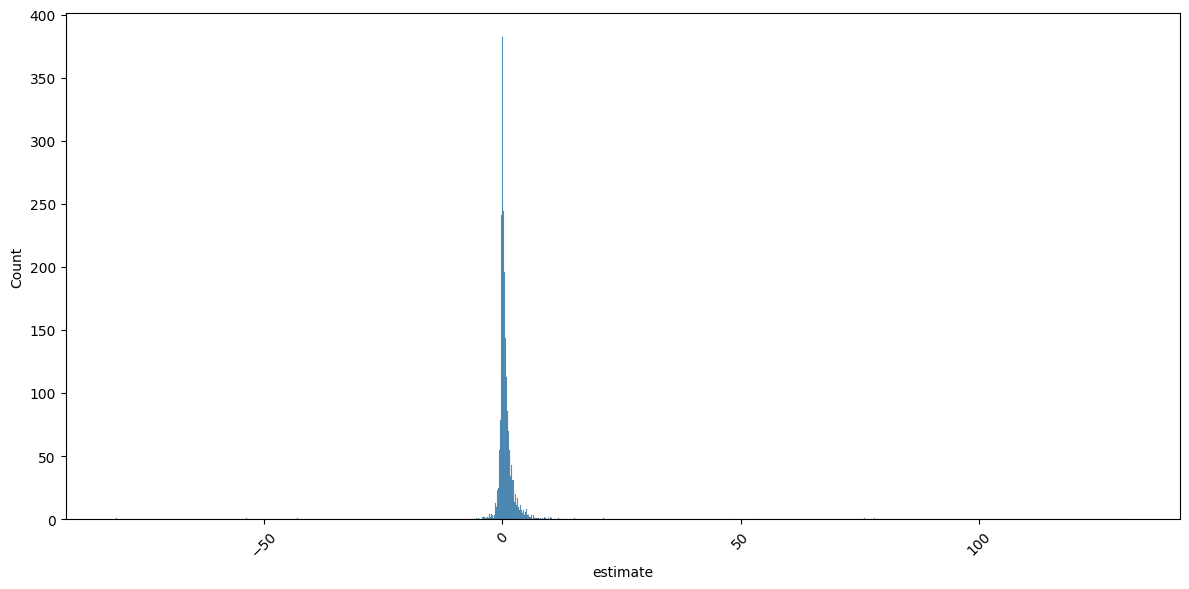

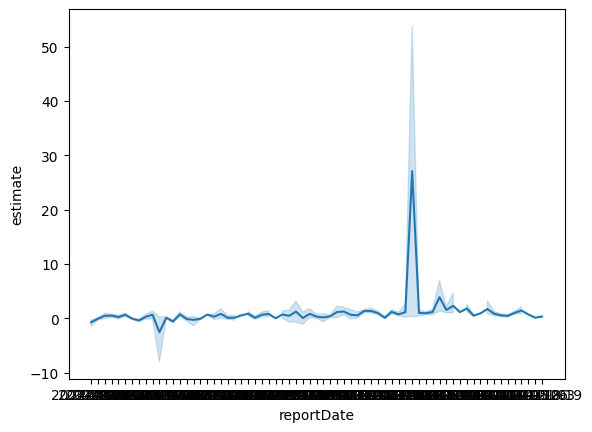

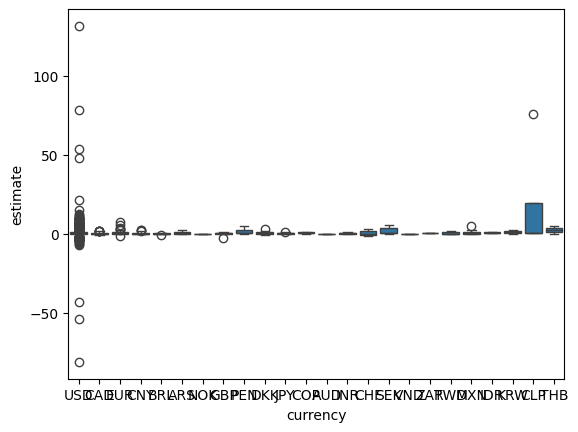

In [ ]:
# Histgram estimate
plt.figure(figsize=(12, 6))  # Mengatur ukuran figure menjadi lebih besar
sns.histplot(filterDateEnding['estimate'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Analisis hubungan waktu dan estimate
sns.lineplot(x='reportDate', y='estimate', data=filterDateEnding)
plt.show()

# Boxplot berdasarkan currency
sns.boxplot(x='currency', y='estimate', data=filterDateEnding)
plt.show()

Berdasarkan dari percobaan untuk memulai proses EDA ternyata pada data estimate masih memiliki tingkat jarak antar data yang sangat jauh dan masih banyak outliernya. maka selanjutnya akan kita gunakan dlu preprocessing dari scikit learn untuk memilih data ini akan di scalling dengan apa. ini termasuk dalam feature engineering
secara langsung terlihat bahwa data paling banyak cenderung mendekati nilai 0 dimana hanya beberapa data yang berada jauh pada rentang data lainnya

In [ ]:
# Preprocessing Data / feature selection
df = filterDateEnding

# Coba konversi kolom 'estimate' ke tipe numerik, dengan error='coerce' akan mengganti nilai yang tidak bisa dikonversi dengan NaN
df['estimate'] = pd.to_numeric(df['estimate'], errors='coerce')

# Konversi kolom tanggal
df['reportDate'] = pd.to_datetime(df['reportDate'], errors='coerce')
df['fiscalDateEnding'] = pd.to_datetime(df['fiscalDateEnding'], errors='coerce')

# Target variable (bisa tergantung pada skenario yang ingin dianalisis)
X = df[['fiscalDateEnding', 'reportDate']]
y = df['estimate']

# Step 2: F-test (menggunakan f_regression untuk target kontinu)
f_values, p_values = f_regression(X, y)
print("F-values:", f_values)
print("P-values:", p_values)

# Step 3: Mutual Information (menggunakan mutual_info_regression untuk target kontinu)
mi = mutual_info_regression(X, y)
print("Mutual Information:", mi)

# Step 4: Perbandingan
comparison = pd.DataFrame({'Feature': X.columns, 'F-value': f_values, 'Mutual Information': mi})
print(comparison)

F-values: [72.0905135  60.70612702]
P-values: [3.25076811e-17 9.19411960e-15]
Mutual Information: [0.16171027 0.22235148]
            Feature    F-value  Mutual Information
0  fiscalDateEnding  72.090513            0.161710
1        reportDate  60.706127            0.222351


Nilai F: Mengukur rasio variansi antar kelompok terhadap variansi dalam kelompok. Nilai F yang lebih tinggi menunjukkan hubungan yang lebih kuat antara fitur dan variabel target.

fiscalDateEnding memiliki nilai F sebesar 72,09.
reportDate memiliki nilai F sebesar 60,71.
Kedua fitur menunjukkan hubungan yang kuat dengan variabel target.
Nilai P: Menunjukkan probabilitas untuk mengamati nilai F yang diberikan di bawah hipotesis nol. Nilai p yang lebih kecil menunjukkan bahwa fitur tersebut signifikan secara statistik terkait dengan variabel target.

Kedua nilai p sangat kecil (dekat dengan nol), menunjukkan bahwa hubungan tersebut signifikan secara statistik.
Informasi Mutual: Mengukur jumlah informasi yang diperoleh tentang variabel target melalui fitur. Nilai yang lebih tinggi menunjukkan ketergantungan yang lebih besar antara fitur dan target.

fiscalDateEnding memiliki skor Informasi Mutual sebesar 0,156.
reportDate memiliki skor Informasi Mutual sebesar 0,222.
reportDate menunjukkan ketergantungan yang sedikit lebih tinggi pada variabel target dibandingkan dengan fiscalDateEnding.
Secara keseluruhan, kedua fitur penting, tetapi reportDate tampaknya memiliki ketergantungan yang lebih kuat pada variabel target berdasarkan Informasi Mutual dan memiliki nilai p yang sedikit lebih rendah.

Terdapat pola yang antara estimate dengan waktu reportDate dibandingkan dengan financialEndingDate. Berarti hal ini dapat diasumsikan jika financialEndingDate dan reportDate yang dekat akan meningkatkan jumlah dividen

In [ ]:
# memfilter data df untuk melihat reportDate dan financialEndingdate yang tidak terlalu jauh maka estimate akan tinggi
# Konversi kolom reportDate dan fiscalDateEnding ke datetime
df['reportDate'] = pd.to_datetime(df['reportDate'])
df['fiscalDateEnding'] = pd.to_datetime(df['fiscalDateEnding'])

# Hitung selisih antara reportDate dan fiscalDateEnding
df['date_diff'] = (df['reportDate'] - df['fiscalDateEnding']).dt.days.abs()

# Tentukan kriteria "tidak terlalu jauh" - misalnya, selisih ≤ 30 hari
threshold = 30
df_filtered = df[(df['date_diff'] <= threshold) & (df['estimate'] > df['estimate'].mean())]

# bagaimana jika dikelompokan per currency tapi cari date diff yang minimum tapi estimate paling maximum a
df_filtered = df_filtered.groupby('currency').agg({'date_diff': 'min', 'estimate': 'max'}).reset_index()
# diurutkan dari estimate terbesar
df_filtered = df_filtered.sort_values(by='estimate', ascending=False)
display(df_filtered)

,currency,date_diff,estimate
14,USD,5,131.54
2,CLP,29,75.94
4,EUR,16,5.57
11,SEK,18,5.37
12,THB,21,5.08
10,MXN,21,4.83
1,CHF,23,2.92
9,KRW,22,2.64
0,CAD,22,2.11
13,TWD,17,1.78


dari Hasil feature selection diketahui bahwa estimate tertinggi jika reportDate dan fiscal rate semakin dekat.. jika jarak keduanya melebar maka jumlah estimate juga akan semakin tinggi

 Berarti betul bahwa semakin dekat reportDate dan fiscalEndingDate akan mempengaruhi nilai estimasi Dividen yg akan dibagikan per lembarnya

Pendefinisian model

In [ ]:
# Konversi kolom reportDate dan fiscalDateEnding ke datetime
df['reportDate'] = pd.to_datetime(df['reportDate'])
df['fiscalDateEnding'] = pd.to_datetime(df['fiscalDateEnding'])

# Buat fitur baru berupa selisih hari antara reportDate dan fiscalDateEnding
df['date_diff'] = (df['reportDate'] - df['fiscalDateEnding']).dt.days

# Pilih fitur yang akan digunakan untuk prediksi
X = df[['date_diff', 'name', 'currency']]
y = df['estimate']

# Encode categorical variables (name dan currency)
X = pd.get_dummies(X, columns=['name', 'currency'])

# Split data menjadi train dan test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 150995968230781.56


MSE yang ditunjukkan sangat besar sehingga data prediksi tidak akan akurat hal ini dikarenakan rentang data yang sangat besar dan rentan akan outlier. maka selanjutnya kita akan mencoba menghilangkan outlier dengan melakukan scaling dan memadatkan data estimate

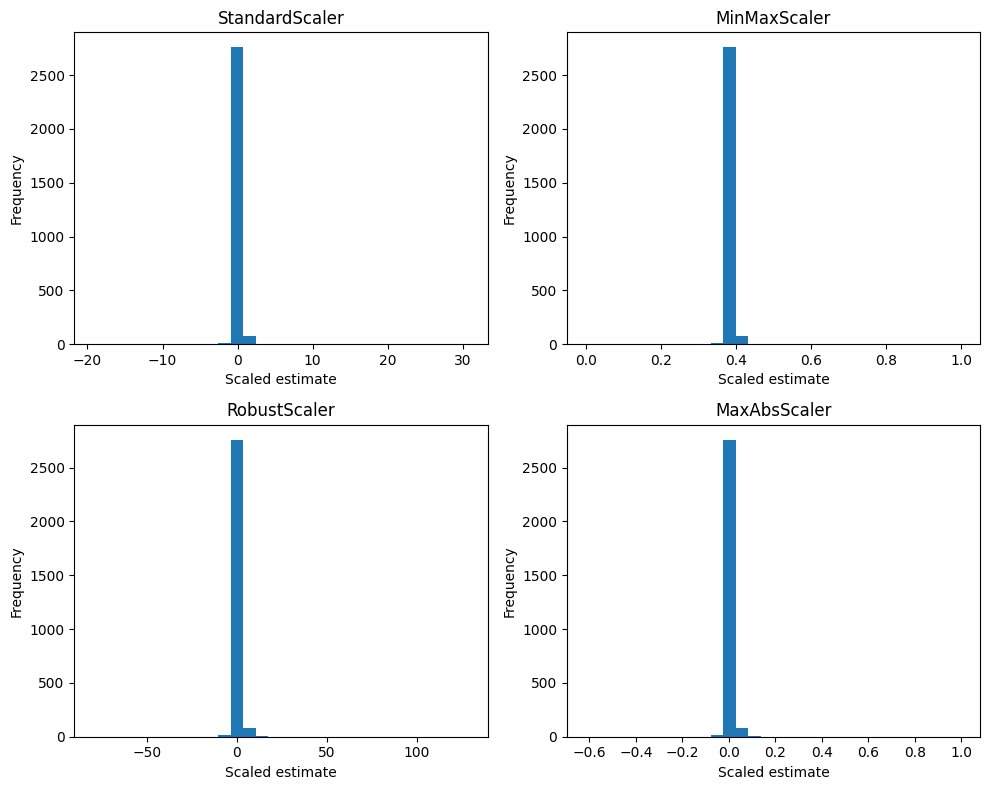

In [ ]:
# Extract the 'estimate' feature
X = filterDateEnding[['estimate']]

# Apply the scalers
scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler(),
    'MaxAbsScaler': MaxAbsScaler()
}

scaled_data = {}
for name, scaler in scalers.items():
    scaled_data[name] = scaler.fit_transform(X)

# Plot the results to compare
plt.figure(figsize=(10, 8))
for i, (name, scaled) in enumerate(scaled_data.items(), 1):
    plt.subplot(2, 2, i)
    plt.hist(scaled, bins=30)
    plt.title(name)
    plt.xlabel('Scaled estimate')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Ternyata data estimate memiliki jarak yang jauh antar data dan memiliki outlier yang cukup tinggi. maka didapatkan intrepretasi dari gambar diatas

Interpretation:

StandardScaler:

The data is centered around 0, but the presence of outliers causes a wide range in the scaled values, making the bulk of the data appear compressed near 0. This shows that StandardScaler is sensitive to outliers.

MinMaxScaler:

The data is scaled to a [0, 1] range. However, because of outliers, most of the data points are clustered near a small range, compressing the information. This scaler is also not robust to outliers.

RobustScaler:

This scaler is designed to be more robust to outliers, using the median and the interquartile range (IQR) for scaling. The histogram still shows some outlier influence, but it handles the data better than StandardScaler and MinMaxScaler.

MaxAbsScaler:

Similar to MinMaxScaler but scales based on the maximum absolute value. It results in a distribution that is less affected by outliers than MinMaxScaler but still exhibits significant clustering near zero.

data contains significant outliers, the RobustScaler is likely the most appropriate choice, as it is less sensitive to extreme values. However, if the outliers are extreme and cause significant scaling issues, we might consider the following additional steps:

1. Outlier Removal or Clipping:

    Identify and remove extreme outliers before scaling. This could be done by setting a threshold for what constitutes an outlier and either removing these data points or clipping them.

In [ ]:
filterDateEnding['estimate'] = pd.to_numeric(filterDateEnding['estimate'], errors='coerce')
df = filterDateEnding[(np.abs(stats.zscore(filterDateEnding['estimate'])) < 3)].copy()
display(df)

,symbol,name,reportDate,fiscalDateEnding,estimate,currency,date_diff
9141,SKYH,Sky Harbour Group Corporation - Class A,2024-08-12,2024-05-31,-0.04,USD,73
7481,ORMP,Oramed Pharmaceuticals Inc,2024-08-08,2024-05-31,0.01,USD,69
8168,PVH,PVH Corp,2024-08-27,2024-05-31,2.29,USD,88
2738,CULP,Culp Inc,2024-08-28,2024-05-31,-0.44,USD,89
7702,PEDH,PEDH,2024-08-08,2024-05-31,0.00,USD,69
...,...,...,...,...,...,...,...
4670,HCKT,Hackett Group Inc (The),2024-11-05,2024-09-30,0.40,USD,36
4662,HCC,Warrior Met Coal Inc,2024-10-30,2024-09-30,1.20,USD,30
4658,HCA,HCA Healthcare Inc,2024-10-22,2024-09-30,4.97,USD,22
4735,HII,Huntington Ingalls Industries Inc,2024-10-31,2024-09-30,4.03,USD,31


2. Log Transformation:

    Apply a log transformation before scaling. This can help reduce the impact of outliers and compress the range of data values.

In [ ]:
# Mengganti nilai negatif dengan NaN atau nilai kecil positif (misal 1)
df['estimate'] = df['estimate'].apply(lambda x: np.nan if x < 0 else x)

# Atau, bisa juga diganti dengan nilai positif kecil seperti 1
# df['estimate'] = df['estimate'].apply(lambda x: 1 if x < 0 else x)

# Terapkan np.log1p() setelah nilai negatif ditangani
df.loc[:, 'estimate'] = np.log1p(df['estimate'])

# Menangani nilai NaN yang mungkin muncul (opsional)
df = df.dropna(subset=['estimate'])

# Lanjutkan dengan analisis atau model
print(df['estimate'])

7481     0.009950
8168     1.190888
7702     0.000000
7558     1.396245
9795     0.157004
           ...   
4670     0.336472
4662     0.788457
4658     1.786747
4735     1.615420
11248    0.058269
Name: estimate, Length: 2054, dtype: float64


Setelah dilakukan pembersihan data dari outlier maka dicek kembali scalingnya

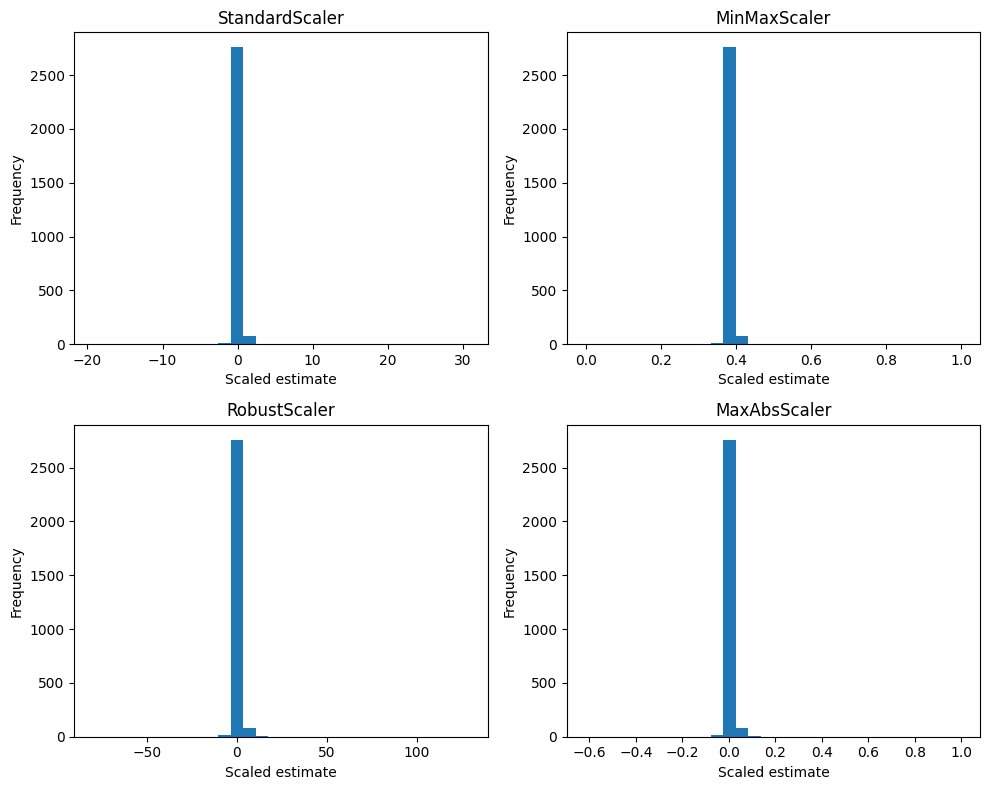

In [ ]:
# Extract the 'estimate' feature
X = filterDateEnding[['estimate']]

# Apply the scalers
scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler(),
    'MaxAbsScaler': MaxAbsScaler()
}

scaled_data = {}
for name, scaler in scalers.items():
    scaled_data[name] = scaler.fit_transform(X)

# Plot the results to compare
plt.figure(figsize=(10, 8))
for i, (name, scaled) in enumerate(scaled_data.items(), 1):
    plt.subplot(2, 2, i)
    plt.hist(scaled, bins=30)
    plt.title(name)
    plt.xlabel('Scaled estimate')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Berikut adalah interpretasi dari histogram diatas setelah penerapan berbagai teknik skala terhadap fitur estimate:

1. StandardScaler (Kiri Atas)
Apa yang dilakukannya: StandardScaler menstandarkan fitur dengan menghilangkan nilai rata-rata dan menskalakan data sehingga memiliki varians unit.
Interpretasi: Data terpusat di sekitar 0 dengan sebagian besar nilai berada dalam rentang -2 hingga 2. Namun, terdapat beberapa outlier yang signifikan, terlihat dari ekor panjang pada distribusi ini. Hal ini menunjukkan bahwa meskipun StandardScaler bekerja dengan baik untuk menstandarkan data, metode ini cukup sensitif terhadap outlier, yang menyebabkan penyebaran yang luas untuk nilai-nilai ekstrem.
2. MinMaxScaler (Kanan Atas)
Apa yang dilakukannya: MinMaxScaler menskalakan data ke dalam rentang tetap, biasanya [0, 1].
Interpretasi: Sebagian besar data terkompresi di antara 0,6 dan 1, dengan sejumlah kecil nilai mendekati 0. Hal ini menunjukkan bahwa outlier memiliki pengaruh besar terhadap proses skala, sehingga mayoritas data terjepit dalam rentang yang sempit. Kompresi ini mengindikasikan bahwa MinMaxScaler sangat terpengaruh oleh outlier.
3. RobustScaler (Kiri Bawah)
Apa yang dilakukannya: RobustScaler menggunakan median dan rentang interkuartil (IQR) untuk skala, membuatnya lebih tahan terhadap outlier.
Interpretasi: Distribusi di sini mirip dengan StandardScaler, tetapi dengan sedikit pengaruh lebih kecil dari outlier. Ekor masih ada, tetapi bagian utama dari data lebih terdistribusi secara kompak di sekitar 0. Hal ini mengonfirmasi bahwa RobustScaler lebih baik dalam menangani outlier dibandingkan StandardScaler, meskipun nilai-nilai ekstrem masih memengaruhi distribusi.
4. MaxAbsScaler (Kanan Bawah)
Apa yang dilakukannya: MaxAbsScaler menskalakan data berdasarkan nilai absolut maksimum, dengan tetap mempertahankan tanda.
Interpretasi: Data diskalakan dalam rentang sekitar -1 hingga 1. Seperti MinMaxScaler, sebagian besar data terkonsentrasi dalam rentang yang sempit (0 hingga 0,2), menunjukkan bahwa outlier masih memengaruhi proses skala. Namun, karena MaxAbsScaler mempertahankan tanda, data tidak terkompresi sebanyak yang terjadi pada MinMaxScaler.

Kesimpulan dan Rekomendasi:

StandardScaler dan RobustScaler memberikan hasil yang serupa, dengan RobustScaler sedikit lebih tahan terhadap outlier. Kedua metode ini masih menunjukkan pengaruh outlier, namun RobustScaler menangani outlier dengan lebih baik.
MinMaxScaler dan MaxAbsScaler sangat dipengaruhi oleh outlier, menyebabkan sebagian besar data terkompresi dalam rentang yang kecil. Hal ini terutama terlihat pada MinMaxScaler, di mana data sangat terjepit di bagian atas skala.
Berdasarkan hasil ini, RobustScaler adalah pilihan yang direkomendasikan jika ingin menangani outlier sambil tetap menskalakan data dengan efektif. Metode ini meminimalkan pengaruh nilai-nilai ekstrem lebih baik daripada scaler lainnya, sambil menjaga distribusi data tetap lebih seimbang.

In [ ]:
# memilih robust scaler
scaler = RobustScaler()

# Terapkan RobustScaler pada kolom 'estimate'
df['estimate'] = scaler.fit_transform(df[['estimate']])

# Periksa hasil
display(df.head())
df.isna().sum()

<ipython-input-547-2b1440f2ebf3>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['estimate'] = scaler.fit_transform(df[['estimate']])


,symbol,name,reportDate,fiscalDateEnding,estimate,currency,date_diff
7481,ORMP,Oramed Pharmaceuticals Inc,2024-08-08,2024-05-31,-0.738642,USD,69
8168,PVH,PVH Corp,2024-08-27,2024-05-31,1.132085,USD,88
7702,PEDH,PEDH,2024-08-08,2024-05-31,-0.754404,USD,69
7558,OXM,Oxford Industries Inc,2024-08-29,2024-05-31,1.457392,USD,90
9795,TBRG,Computer Programs & Systems Inc,2024-08-08,2024-06-30,-0.505694,USD,39


,0
0,
symbol,0
name,0
reportDate,0
fiscalDateEnding,0
estimate,0
currency,0
date_diff,0


Setelahnya mari kita coba lakukan langkah langkah EDA

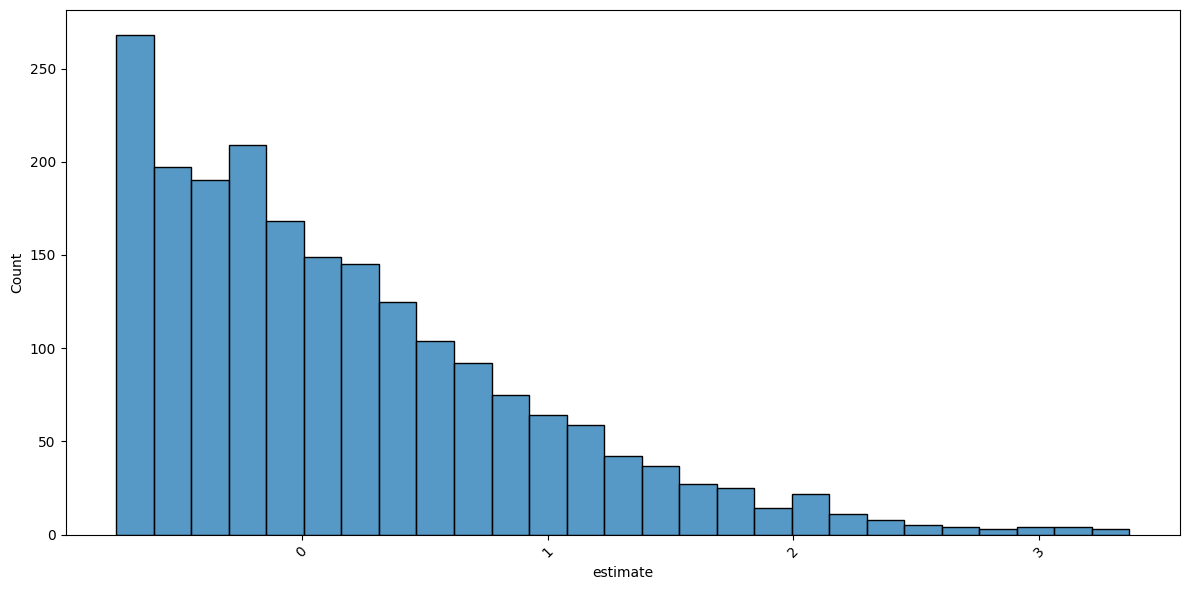

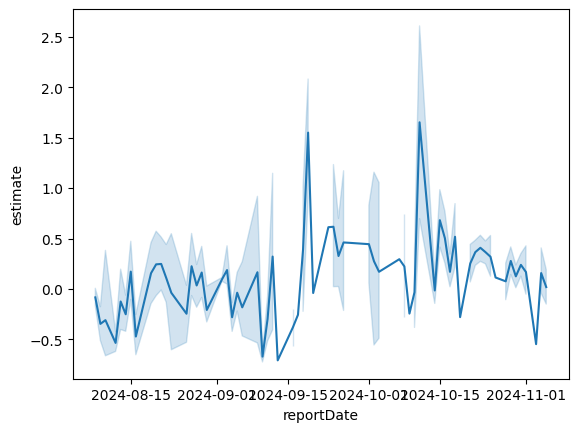

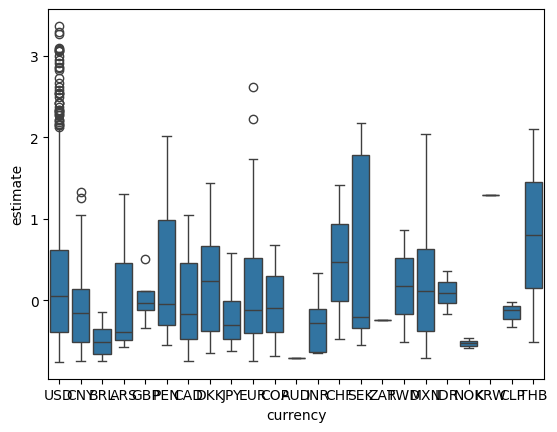

In [ ]:
# Histgram estimate
plt.figure(figsize=(12, 6))  # Mengatur ukuran figure menjadi lebih besar
sns.histplot(df['estimate'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Analisis hubungan waktu dan estimate
sns.lineplot(x='reportDate', y='estimate', data=df)
plt.show()

# Boxplot berdasarkan currency
sns.boxplot(x='currency', y='estimate', data=df)
plt.show()

Grafik yang kamu tampilkan adalah histogram dari kolom estimate yang telah ditransformasi menggunakan np.log1p(). Histogram ini menunjukkan distribusi frekuensi nilai estimate setelah transformasi.

Interpretasi Histogram:
Distribusi:

Sebagian besar nilai estimate terdistribusi di sekitar 0 setelah transformasi logaritmik.
Frekuensi data menurun seiring meningkatnya nilai estimate, yang berarti setelah transformasi log, sebagian besar estimate bernilai kecil, sementara hanya sedikit yang bernilai lebih besar.
Bentuk Distribusi:

Bentuk histogram ini menunjukkan distribusi yang mirip dengan distribusi exponential decay, di mana lebih banyak nilai kecil yang diamati daripada nilai besar.
Ini sering terjadi pada data asli yang sangat skewed (berkonsentrasi di dekat nol dan memiliki ekor panjang di sisi kanan).
Log Transform:

Transformasi log membantu mengatasi skewness (kemencengan) dalam data asli, membuatnya lebih simetris dan lebih cocok untuk analisis yang mengasumsikan distribusi mendekati normal, seperti regresi linear.
Kesimpulan:
Efek Transformasi: Dengan menerapkan transformasi log, kamu telah berhasil "memadatkan" rentang nilai estimate, sehingga data yang awalnya mungkin sangat spread out sekarang lebih terkonsentrasi. Ini bisa membantu dalam meningkatkan performa model jika data asli sangat skewed.
Distribusi yang Skewed: Meskipun ada transformasi, distribusi tetap menunjukkan sifat skewed, namun jauh lebih terkontrol dibandingkan tanpa transformasi.
Jika tujuanmu adalah untuk melihat bagaimana distribusi estimate berubah setelah transformasi, histogram ini menunjukkan bahwa transformasi berhasil mengurangi skewness, meskipun ada beberapa nilai estimate yang masih relatif besar.

In [ ]:
# Konversi kolom reportDate dan fiscalDateEnding ke datetime
df['reportDate'] = pd.to_datetime(df['reportDate'])
df['fiscalDateEnding'] = pd.to_datetime(df['fiscalDateEnding'])

# Buat fitur baru berupa selisih hari antara reportDate dan fiscalDateEnding
df['date_diff'] = (df['reportDate'] - df['fiscalDateEnding']).dt.days

# Pilih fitur yang akan digunakan untuk prediksi
X = df[['date_diff', 'name', 'currency']]
y = df['estimate']

# Encode categorical variables (name dan currency)
X = pd.get_dummies(X, columns=['name', 'currency'])

# Split data menjadi train dan test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred_linear = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred_linear)
print(f'Mean Squared Error: {mse}')

# resultsLinear = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
# print(results.head())

Mean Squared Error: 0.5359570883641291


setelah melakukan scaling, maka mse menjadi lebih baik
Nilai Mean Squared Error (MSE) sebesar 0.5359570883641291 menunjukkan bahwa model prediksimu menghasilkan kesalahan rata-rata sebesar 0.536 pada skala nilai estimate yang telah ditransformasi dengan log.

Interpretasi MSE:
MSE Rendah: Secara umum, semakin rendah nilai MSE, semakin baik performa model dalam memprediksi nilai target (estimate dalam hal ini).
Skala MSE: Karena kamu telah melakukan transformasi log pada target (estimate), MSE ini dihitung pada skala logaritmik. Oleh karena itu, MSE tidak secara langsung menunjukkan kesalahan pada skala asli, tetapi pada skala yang telah ditransformasi.
Kesimpulan:
Model yang Layak: Nilai MSE ini relatif rendah setelah transformasi log, yang menunjukkan bahwa modelmu melakukan prediksi dengan cukup baik pada skala log.
Langkah Selanjutnya: Kamu dapat mempertimbangkan untuk melakukan evaluasi tambahan seperti R-squared atau membandingkan hasil prediksi dengan nilai asli setelah membalikkan transformasi log (menggunakan np.expm1() pada prediksi) untuk mendapatkan pemahaman yang lebih baik tentang akurasi model pada skala asli.

In [ ]:
resultsLinear = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_linear})

print(resultsLinear.head())

         Actual  Predicted
238   -0.707580   0.215154
10540  0.709718   0.216379
467   -0.176772   0.218420
10802  0.836514   0.216379
9963  -0.338792  -0.490317


In [ ]:
# Konversi kolom reportDate dan fiscalDateEnding ke datetime
df['reportDate'] = pd.to_datetime(df['reportDate'])
df['fiscalDateEnding'] = pd.to_datetime(df['fiscalDateEnding'])

# Buat fitur baru berupa selisih hari antara reportDate dan fiscalDateEnding
df['date_diff'] = (df['reportDate'] - df['fiscalDateEnding']).dt.days

# Pilih fitur yang akan digunakan untuk prediksi
X = df[['date_diff', 'name', 'currency']]
y = df['estimate']

# Encode categorical variables (name dan currency)
X = pd.get_dummies(X, columns=['name', 'currency'])

# Split data menjadi train dan test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define and train the model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 0.669923235611435


Ternyata hasil model yang lebih baik didapatkan dari linearRegresion ,sehingga kita menggunakan model linear regresion dalam melakukan estimasi estimate

In [ ]:
# Melakukan prediksi pada data test
y_pred_log = model.predict(X_test)

# Membalikkan transformasi log (kembali ke skala asli)
y_pred_original = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

# Menghitung R-squared pada skala log
r2_log = r2_score(y_test, y_pred_log)
print(f'R-squared (Log Scale): {r2_log}')

# Menghitung R-squared pada skala asli
r2_original = r2_score(y_test_original, y_pred_original)
print(f'R-squared (Original Scale): {r2_original}')

# Menghitung MSE pada skala asli
mse_original = mean_squared_error(y_test_original, y_pred_original)
print(f'Mean Squared Error (Original Scale): {mse_original}')

R-squared (Log Scale): -0.26489968848709333
R-squared (Original Scale): -0.13537232374408692
Mean Squared Error (Original Scale): 5.3631068826733355


Hasil evaluasi dengan R-squared dan Mean Squared Error (MSE) menunjukkan beberapa hal penting tentang performa model:

1. R-squared (Log Scale): -0.278
Interpretasi: R-squared yang negatif menunjukkan bahwa model prediksi pada skala logaritmik ini lebih buruk daripada model rata-rata sederhana (model yang hanya memprediksi rata-rata dari semua nilai estimate).
Artinya: Model tidak mampu menangkap variasi data dengan baik pada skala logaritmik. Prediksi yang dihasilkan justru memperburuk estimasi dibandingkan jika hanya menggunakan rata-rata sebagai prediksi.
2. R-squared (Original Scale): -0.138
Interpretasi: Sama seperti pada skala log, R-squared yang negatif di sini juga menunjukkan bahwa model kurang efektif. Meskipun sedikit lebih baik dibandingkan dengan skala log (-0.138 vs -0.278), hasil ini masih menunjukkan bahwa model tidak mampu menangkap variasi data pada skala asli dengan baik.
Artinya: Modelmu tidak memberikan prediksi yang lebih baik daripada sekadar menggunakan rata-rata estimate.
3. Mean Squared Error (Original Scale): 5.377
Interpretasi: MSE ini mengindikasikan rata-rata kesalahan kuadrat dari prediksi model pada skala asli. Karena ini pada skala asli, nilai ini menunjukkan bahwa kesalahan prediksi rata-rata adalah sekitar 5.377 unit kuadrat dari estimate.
Artinya: Nilai MSE ini cukup tinggi, yang sejalan dengan R-squared yang negatif. Ini mengkonfirmasi bahwa model tidak bekerja dengan baik pada skala asli.
Kesimpulan:
Model Perlu Perbaikan: Nilai R-squared yang negatif pada kedua skala (log dan asli) menunjukkan bahwa model saat ini tidak bekerja dengan baik. Modelmu bahkan tidak lebih baik dari sekadar memprediksi rata-rata estimate.
MSE Tinggi: MSE pada skala asli juga cukup tinggi, menunjukkan bahwa prediksi yang dihasilkan oleh model tidak akurat.

Langkah Selanjutnya:
tidak usah dilakukan pada skala sebenarnya lanjutkan dengan hasil prediksi linear regression

In [ ]:
df

,symbol,name,reportDate,fiscalDateEnding,estimate,currency,date_diff
7481,ORMP,Oramed Pharmaceuticals Inc,2024-08-08,2024-05-31,-0.738642,USD,69
8168,PVH,PVH Corp,2024-08-27,2024-05-31,1.132085,USD,88
7702,PEDH,PEDH,2024-08-08,2024-05-31,-0.754404,USD,69
7558,OXM,Oxford Industries Inc,2024-08-29,2024-05-31,1.457392,USD,90
9795,TBRG,Computer Programs & Systems Inc,2024-08-08,2024-06-30,-0.505694,USD,39
...,...,...,...,...,...,...,...
4670,HCKT,Hackett Group Inc (The),2024-11-05,2024-09-30,-0.221397,USD,36
4662,HCC,Warrior Met Coal Inc,2024-10-30,2024-09-30,0.494594,USD,30
4658,HCA,HCA Healthcare Inc,2024-10-22,2024-09-30,2.075988,USD,22
4735,HII,Huntington Ingalls Industries Inc,2024-10-31,2024-09-30,1.804589,USD,31


selanjutnya kita akan mengetes dengan input data baru yagn diolah dengan model linear regression yang tadi sudah di persiapkan untuk melakukan estimate pada input data baru tadi

kembali kita melakukan tarik data dari api

In [ ]:
import csv
import requests

# replace the "demo" apikey below with your own key from https://www.alphavantage.co/support/#api-key
CSV_URL = 'https://www.alphavantage.co/query?function=EARNINGS_CALENDAR&horizon=1month&apikey=5PU70RNGMT9HHOOV'

temp = []
with requests.Session() as s:
    download = s.get(CSV_URL)
    decoded_content = download.content.decode('utf-8')
    cr = csv.reader(decoded_content.splitlines(), delimiter=',')
    my_list = list(cr)
    for row in my_list:
        # display(row)
        temp.append(row)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# ubah bentuk datanya kedalam dataframe
dataDividen = pd.DataFrame(temp)
display (dataDividen)

# lalu simpan dulu datanya ke dalam komputer kita untuk melakukan pengolahan terlebih dahulu sehingga datasetnya persistent
dataDividen.to_csv('dataBarudividend.csv')


,0,1,2,3,4,5
0,symbol,name,reportDate,fiscalDateEnding,estimate,currency
1,A,Agilent Technologies Inc,2024-08-21,2024-07-31,1.26,USD
2,AA,Alcoa Corp,2024-10-16,2024-09-30,0.51,USD
3,AAALY,AAALY,2024-08-08,2024-06-30,,EUR
4,AABVF,AABVF,2024-09-15,2024-07-31,,CAD
...,...,...,...,...,...,...
11953,ZYME,Zymeworks BC Inc,2024-11-05,2024-09-30,-0.46,USD
11954,ZYNE,ZYNE,2024-08-12,2024-06-30,,USD
11955,ZYXI,Zynex Inc,2024-10-24,2024-09-30,0.06,USD
11956,ZZHGF,ZZHGF,2024-08-27,2024-06-30,,CNY


In [ ]:
# drop dlu kolom estimatenya
df_new = pd.read_csv('dataBarudividend.csv')

# membuat data ke 0 menjadi data label
dataDividenOlahColumns = dataDividenOlah.iloc[0]
display (dataDividenOlahColumns.shape)
dataDividenOlah.columns = dataDividenOlahColumns
LabelizedDividenData = dataDividenOlah.drop([0,0], axis = 0)
# drop colums index ke 1
LabelizedDividenData = LabelizedDividenData.drop([0], axis = 1)
display (LabelizedDividenData,'^^^^ berhasil labelling')
df_new = LabelizedDividenData.drop(columns=['estimate'], errors='ignore')
display(df_new)

(7,)

,symbol,name,reportDate,fiscalDateEnding,estimate,currency
1,A,Agilent Technologies Inc,2024-08-21,2024-07-31,1.26,USD
2,AA,Alcoa Corp,2024-10-16,2024-09-30,0.51,USD
3,AAALY,AAALY,2024-08-08,2024-06-30,NaN,EUR
4,AABVF,AABVF,2024-09-15,2024-07-31,NaN,CAD
5,AACAF,AACAF,2024-08-22,2024-06-30,NaN,CNY
...,...,...,...,...,...,...
11246,ZYME,Zymeworks BC Inc,2024-11-05,2024-09-30,-0.45,USD
11247,ZYNE,ZYNE,2024-08-12,2024-06-30,NaN,USD
11248,ZYXI,Zynex Inc,2024-10-24,2024-09-30,0.06,USD
11249,ZZHGF,ZZHGF,2024-08-27,2024-06-30,NaN,CNY


'^^^^ berhasil labelling'

,symbol,name,reportDate,fiscalDateEnding,currency
1,A,Agilent Technologies Inc,2024-08-21,2024-07-31,USD
2,AA,Alcoa Corp,2024-10-16,2024-09-30,USD
3,AAALY,AAALY,2024-08-08,2024-06-30,EUR
4,AABVF,AABVF,2024-09-15,2024-07-31,CAD
5,AACAF,AACAF,2024-08-22,2024-06-30,CNY
...,...,...,...,...,...
11246,ZYME,Zymeworks BC Inc,2024-11-05,2024-09-30,USD
11247,ZYNE,ZYNE,2024-08-12,2024-06-30,USD
11248,ZYXI,Zynex Inc,2024-10-24,2024-09-30,USD
11249,ZZHGF,ZZHGF,2024-08-27,2024-06-30,CNY


In [ ]:
# Terapkan encoding yang sama pada data baru
df_new = pd.get_dummies(df_new, columns=['name', 'currency','reportDate','fiscalDateEnding','symbol'])
display(df_new)
# Jika ada fitur yang mungkin hilang dari df_new yang ada di model sebelumnya, tambahkan kolom yang hilang
for col in X.columns:
    if col not in df_new.columns:
        df_new[col] = 0

# # Urutkan kolom agar sesuai dengan urutan kolom pada data pelatihan
df_new = df_new[X.columns]
df_new


,name_1-800 Flowers.com Inc - Class A,name_10x Genomics Inc - Class A,name_111 Inc,name_17 Education & Technology Group Inc,name_180 Degree Capital Corp,name_180 Life Sciences Corp,name_1847 Holdings LLC,name_1895 Bancorp of Wisconsin Inc,name_1st Source Corp,name_22nd Century Group Inc,...,symbol_ZUMZ,symbol_ZUO,symbol_ZURVY,symbol_ZVRA,symbol_ZWS,symbol_ZYME,symbol_ZYNE,symbol_ZYXI,symbol_ZZHGF,symbol_ZZHGY
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
11247,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
11248,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
11249,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


,date_diff,name_1st Source Corp,name_360 DigiTech Inc,name_3M Company,name_A-Mark Precious Metals Inc,name_A.O. Smith Corp,name_AAON Inc,name_AAR Corp,name_AAVVF,name_ABBNY,...,currency_JPY,currency_KRW,currency_MXN,currency_NOK,currency_PEN,currency_SEK,currency_THB,currency_TWD,currency_USD,currency_ZAR
1,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
11247,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
11248,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
11249,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
# Gunakan model untuk membuat prediksi
y_pred_new = model.predict(df_new)

# Tambahkan hasil prediksi ke DataFrame data baru
df_new['estimate'] = y_pred_new

In [ ]:
# Simpan DataFrame dengan prediksi ke file CSV
# df_new.to_csv('new_data_with_predictions.csv', index=False)

display(df_new.head())


,date_diff,name_1st Source Corp,name_360 DigiTech Inc,name_3M Company,name_A-Mark Precious Metals Inc,name_A.O. Smith Corp,name_AAON Inc,name_AAR Corp,name_AAVVF,name_ABBNY,...,currency_KRW,currency_MXN,currency_NOK,currency_PEN,currency_SEK,currency_THB,currency_TWD,currency_USD,currency_ZAR,estimate
1,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,0.545793
2,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,-0.095046
3,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0.183819
4,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,-0.065459
5,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0.003600


In [ ]:
# tampilkan encoding true dan nilai estimatenya
df_new = pd.read_csv('new_data_with_predictions.csv')
display(df_new)
# tunjukan hanya nilai true pada columnya diikuti dengan estimate
df_filtered = df_new[df_new['currency_USD'] == True]
display(df_filtered)

,date_diff,name_1st Source Corp,name_360 DigiTech Inc,name_3M Company,name_A-Mark Precious Metals Inc,name_A.O. Smith Corp,name_AAON Inc,name_AAR Corp,name_AAVVF,name_ABBNY,...,currency_KRW,currency_MXN,currency_NOK,currency_PEN,currency_SEK,currency_THB,currency_TWD,currency_USD,currency_ZAR,estimate
0,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,0.545793
1,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,-0.095046
2,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0.183819
3,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,-0.065459
4,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0.003600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11245,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,0.227812
11246,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,0.227812
11247,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,-0.652300
11248,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0.003600


,date_diff,name_1st Source Corp,name_360 DigiTech Inc,name_3M Company,name_A-Mark Precious Metals Inc,name_A.O. Smith Corp,name_AAON Inc,name_AAR Corp,name_AAVVF,name_ABBNY,...,currency_KRW,currency_MXN,currency_NOK,currency_PEN,currency_SEK,currency_THB,currency_TWD,currency_USD,currency_ZAR,estimate
0,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,0.545793
1,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,-0.095046
6,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,0.227812
7,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,0.227812
8,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,0.227812
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11243,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,0.227812
11244,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,-0.302765
11245,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,0.227812
11246,0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,0.227812
